In [2]:
# EDA_Cancer_Datasets.ipynb

In [3]:
# EDA for Breast Cancer Dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


--- Breast Cancer Dataset EDA ---

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  per

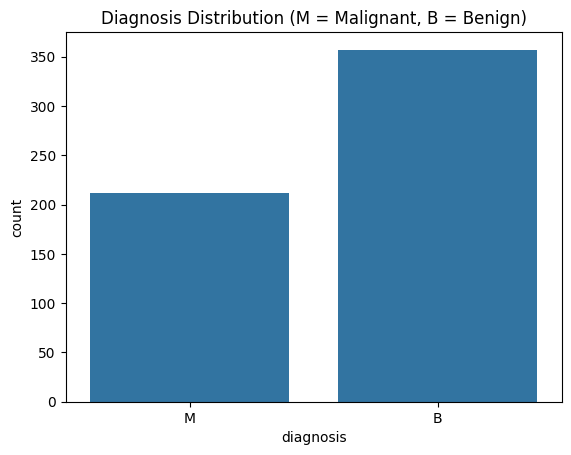

In [5]:
print("\n--- Breast Cancer Dataset EDA ---\n")
breast_df = pd.read_csv("C:/Users/ashfa/OneDrive/Desktop/Cancer_Detection_System/datasets/breast/breast_data.csv")
print(breast_df.head())
print(breast_df.info())
print(breast_df["diagnosis"].value_counts())
sns.countplot(x="diagnosis", data=breast_df)
plt.title("Diagnosis Distribution (M = Malignant, B = Benign)")
plt.show()

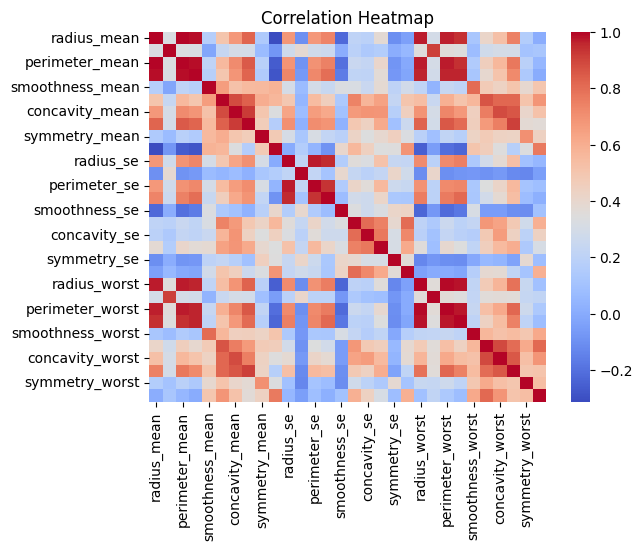

In [8]:
sns.heatmap(breast_df.drop(columns=["id", "Unnamed: 32", "diagnosis"]).corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [9]:
# EDA for Lung Cancer Dataset
import os
import cv2
import numpy as np


--- Lung Cancer Dataset EDA ---

Lung Cancer Class Distribution: {'benign cases': 120, 'malignant cases': 561, 'normal cases': 416}


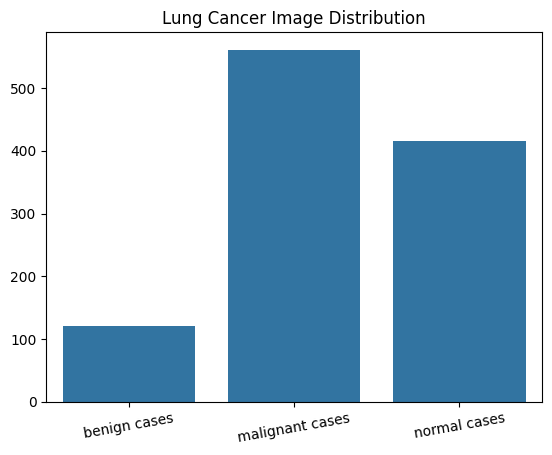

In [15]:
print("\n--- Lung Cancer Dataset EDA ---\n")
lung_dir = "C:/Users/ashfa/OneDrive/Desktop/Cancer_Detection_System/datasets/lung/lung_dataset"
classes = ["benign cases", "malignant cases", "normal cases"]
lung_counts = {}

for cls in classes:
    count = len(os.listdir(os.path.join(lung_dir, cls)))
    lung_counts[cls] = count

print("Lung Cancer Class Distribution:", lung_counts)
sns.barplot(x=list(lung_counts.keys()), y=list(lung_counts.values()))
plt.title("Lung Cancer Image Distribution")
plt.xticks(rotation=10)
plt.show()


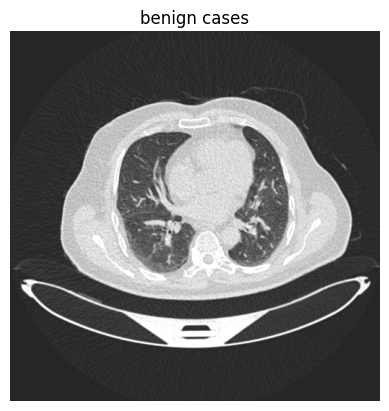

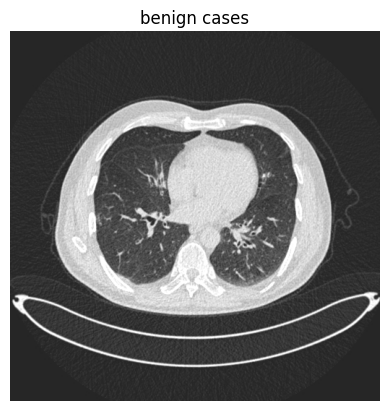

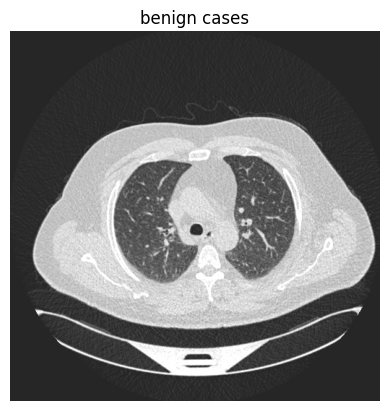

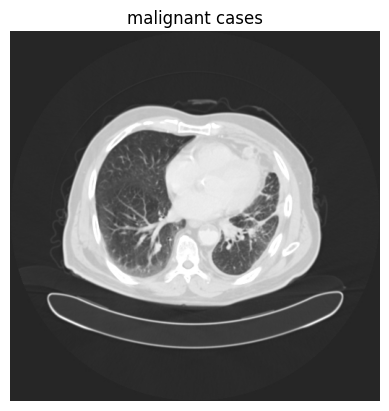

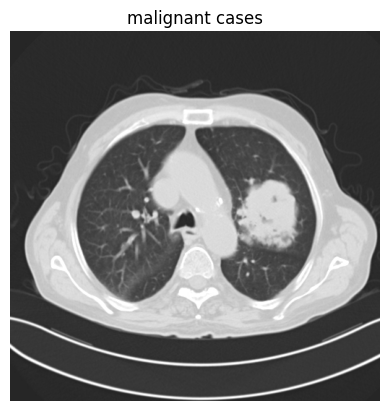

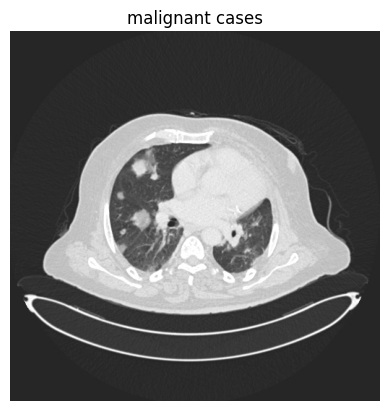

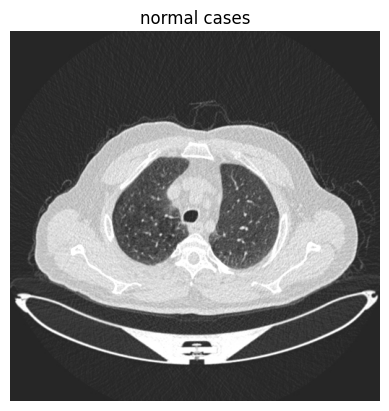

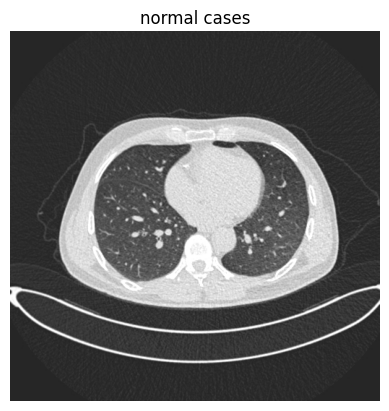

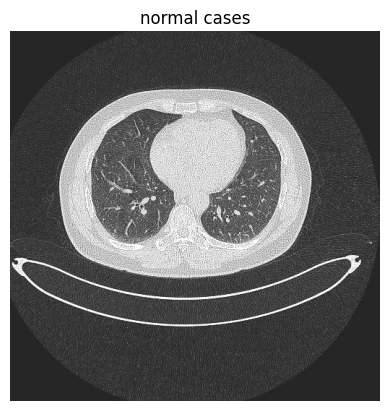

In [16]:
# Visualize few images
for cls in classes:
    img_path = os.path.join(lung_dir, cls)
    imgs = os.listdir(img_path)[:3]
    for img in imgs:
        image = cv2.imread(os.path.join(img_path, img))
        if image is not None:
            plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
            plt.title(cls)
            plt.axis("off")
            plt.show()



--- Skin Cancer Dataset EDA ---

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


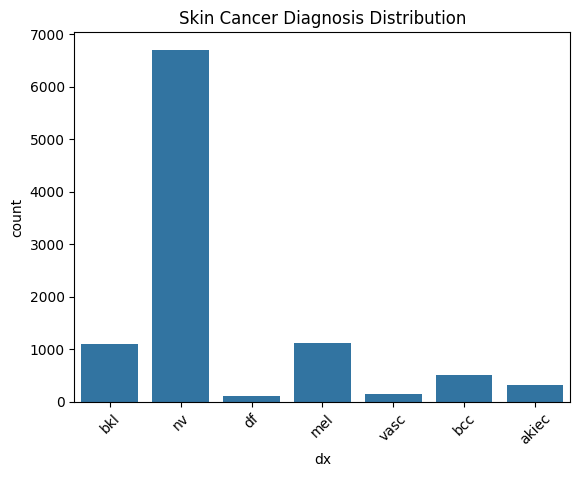

In [18]:
# EDA for Skin Cancer Dataset
print("\n--- Skin Cancer Dataset EDA ---\n")
skin_meta = pd.read_csv("C:/Users/ashfa/OneDrive/Desktop/Cancer_Detection_System/datasets/skin/HAM10000_metadata.csv")
print(skin_meta.head())
print(skin_meta["dx"].value_counts())
sns.countplot(x="dx", data=skin_meta)
plt.title("Skin Cancer Diagnosis Distribution")
plt.xticks(rotation=45)
plt.show()

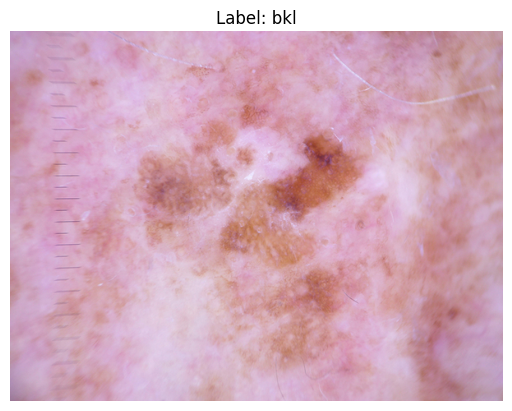

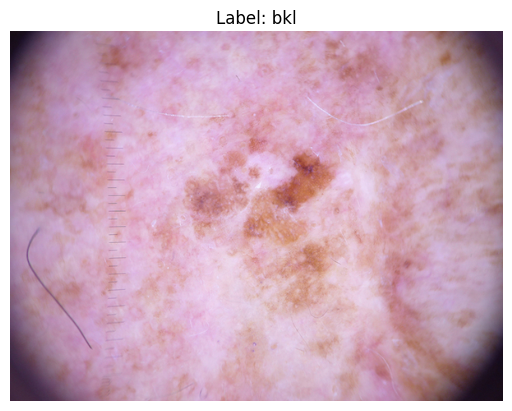

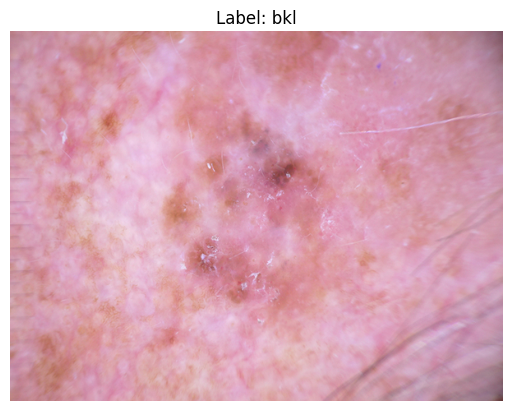

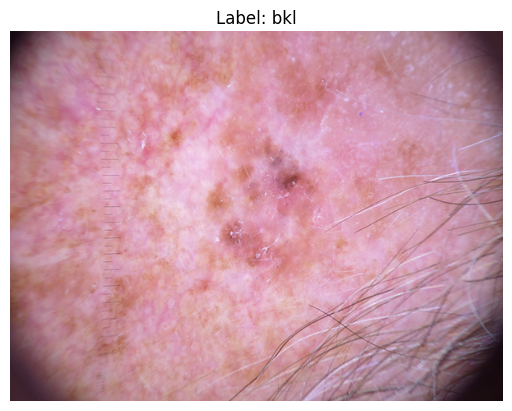

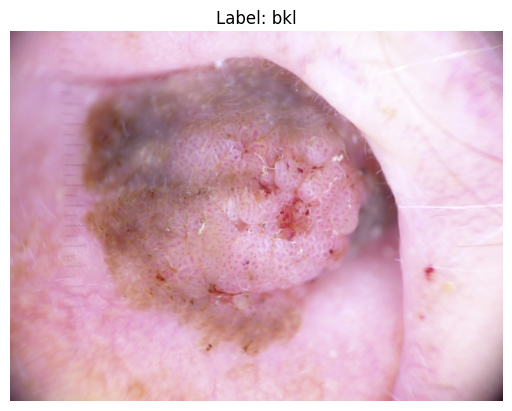

In [23]:
# Visualize image samples
img_dir = "C:/Users/ashfa/OneDrive/Desktop/Cancer_Detection_System/datasets/skin/images"  

image_map = {}
for file in os.listdir(img_dir):
    image_map[file.split(".")[0]] = os.path.join(img_dir, file)

sample_ids = skin_meta["image_id"][:5]
for img_id in sample_ids:
    img_path = image_map.get(img_id)
    if img_path and os.path.exists(img_path):
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.imshow(image)
        label = skin_meta[skin_meta.image_id == img_id]["dx"].values[0]
        plt.title(f"Label: {label}")
        plt.axis("off")
        plt.show()
